# Fornax 2019 Models

Some I/O and plotting using the Fornax 3D models from [Vartanyan, Burrows, et al., MNRAS 482(1):351, 2019](https://arxiv.org/abs/1809.05106), which express the angular dependence of the neutrino luminosity from CCSNe in terms of a spherical harmonic expansion up to degree $\ell=2$. Note: Caching and plotting the angular dependence requires the `healpy` package, which can be installed via `pip install healpy`.

The data are available on [the Burrows group website](https://www.astro.princeton.edu/~burrows/nu-emissions.3d/).

In [1]:
from snewpy.flavor import ThreeFlavor
from snewpy.models.ccsn import Fornax_2019

from astropy import units as u

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import healpy as hp
    healpy_available = True
except ModuleNotFoundError:
    healpy_available = False

mpl.rc('font', size=16)
%matplotlib inline

## Initialization and Time Evolution of the Energy Spectrum

To start, let’s see what progenitors are available for the `Fornax_2019` model. We can use the `param` property to view all physics parameters and their possible values:

In [2]:
Fornax_2019.param

{'progenitor_mass': <Quantity [ 9., 10., 12., 13., 14., 15., 19., 25., 60.] solMass>}

We’ll initialise one of these progenitors and plot the evolution of the predicted neutrino spectrum across four time steps. If this is the first time you’re using a progenitor, snewpy will automatically download the required data files for you.

In [3]:
model = Fornax_2019(progenitor_mass=10*u.solMass)
model

**Fornax_2019 Model**: lum_spec_10M.h5

|Parameter|Value|
|:--------|:----:|
|Progenitor mass | $10$ $\mathrm{M_{\odot}}$|

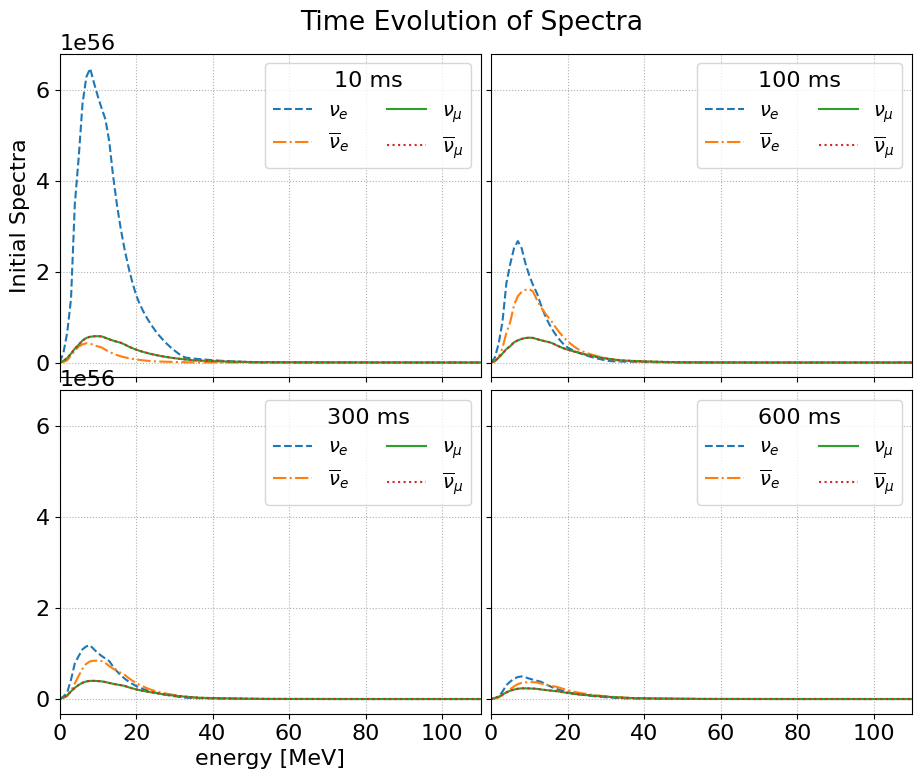

In [4]:
E = np.arange(0,111) * u.MeV
t = [10., 100., 300., 600.] * u.ms
theta = 23.55*u.degree
phi = 22.5*u.degree
spectra = model.get_initial_spectra(t, E, theta, phi)

fig, axes = plt.subplots(2,2, figsize=(11,8), sharex=True, sharey=True,
                         gridspec_kw = {'hspace':0.04, 'wspace':0.025})
axes = axes.flatten()

for i in range(len(t)):
    ax = axes[i]
    lines = ['--', '-.', '-', ':']
    for line, flavor in zip(lines, ThreeFlavor):
        ax.plot(E, spectra[flavor].array.squeeze()[i], ls=line, label=flavor.to_tex())
    ax.legend(fontsize=14, ncol=2, loc='upper right', title=f'{t[i]:g}')
    ax.set(xlim=(E[0].to_value('MeV'), E[-1].to_value('MeV')))
    ax.grid(ls=':')

axes[0].set(ylabel='Initial Spectra')
axes[2].set(xlabel=r'energy [MeV]');

fig.suptitle('Time Evolution of Spectra')
fig.subplots_adjust(top=0.925, bottom=0.1)

### Plot $L_\nu(t,\theta,\varphi)$ at Several Times

Plot the angular dependence $L(t)$ for several values of $t$.

In [5]:
model.luminosity[ThreeFlavor.NU_E][400].to_value('1e52*erg/s')

array([2.32499046, 2.39682712, 2.43564407, 2.34928962, 2.26835806,
       2.30492959, 2.36698253, 2.44628575, 2.49760023, 2.46274799,
       2.36092928, 2.27990676, 2.22562924, 2.25647476, 2.29563636,
       2.34275014, 2.40709077, 2.48318758, 2.54052106, 2.54182998,
       2.47499428, 2.36805195, 2.27155687, 2.22313417, 2.19797548,
       2.23208999, 2.26730974, 2.29757126, 2.32924546, 2.37373695,
       2.43624244, 2.50794759, 2.56695801, 2.58806316, 2.55607986,
       2.4751757 , 2.36864555, 2.2689344 , 2.20319248, 2.18212996,
       2.17392383, 2.21748759, 2.26415783, 2.2975713 , 2.32014917,
       2.34833029, 2.39842539, 2.47206605, 2.55053309, 2.60200448,
       2.59804312, 2.52999398, 2.41572499, 2.29250871, 2.19970474,
       2.16069975, 2.20586087, 2.26552035, 2.31001811, 2.33145724,
       2.34413854, 2.37209416, 2.4302203 , 2.51079031, 2.58397341,
       2.61266538, 2.57334592, 2.47087857, 2.33842774, 2.22212066,
       2.15881622, 2.15927445, 2.19644598, 2.2648748 , 2.32493

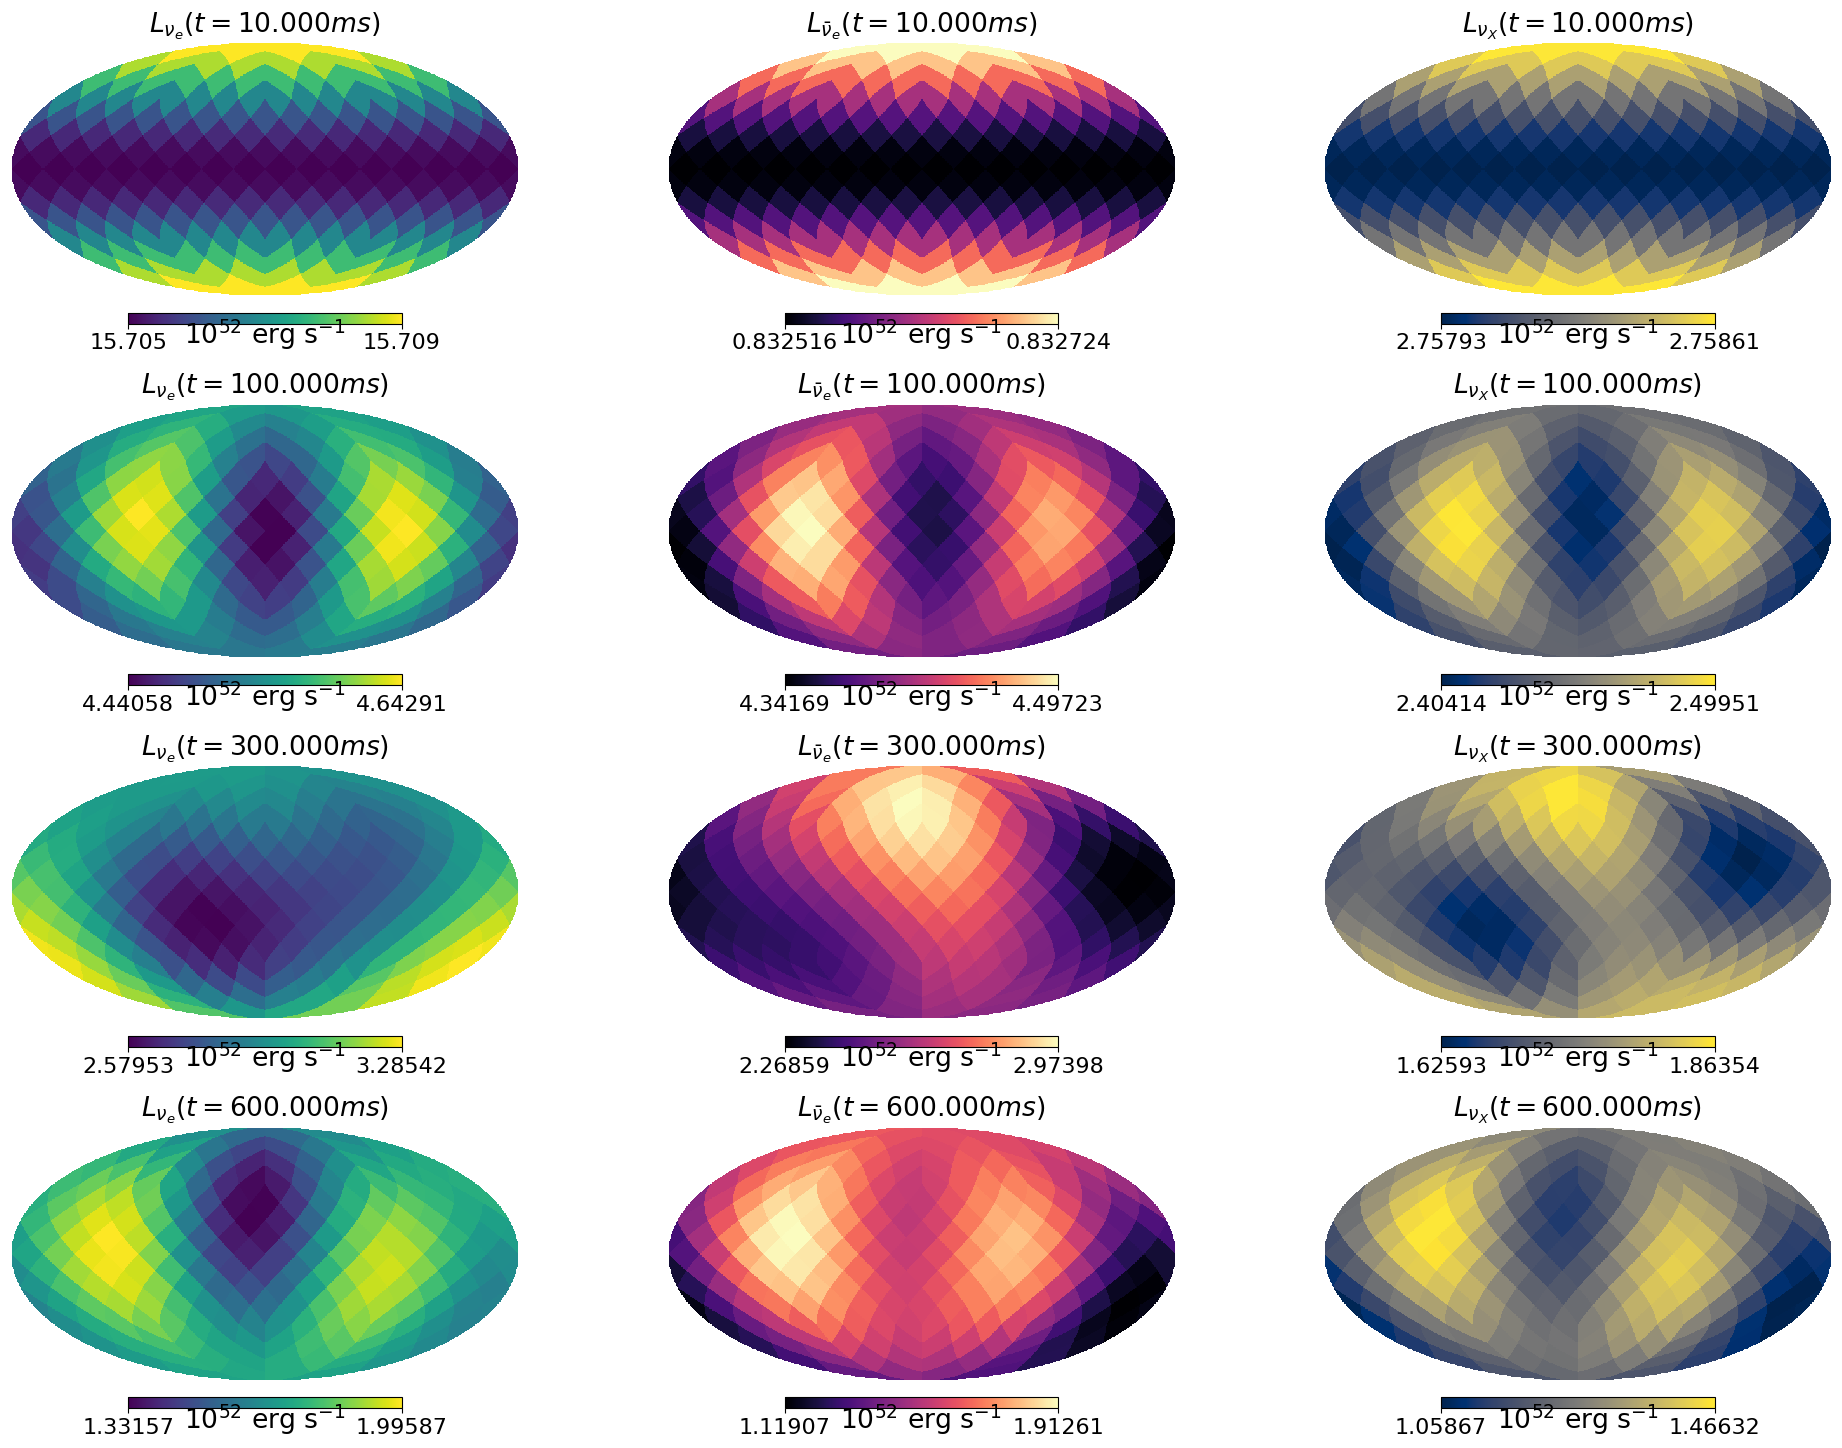

In [6]:
if healpy_available:
    times = np.asarray([10., 100., 300., 600.]) * u.ms
    nt = len(times)

    fig, axes = plt.subplots(nt,3, figsize=(8*3, nt*4.5))

    #- Get luminosity for a fixed list of times
    idx = [np.abs(t - model.time).argmin() for t in times]
    L_nue = model.luminosity[ThreeFlavor.NU_E].to('1e52*erg/s')[idx]
    L_nue_bar = model.luminosity[ThreeFlavor.NU_E_BAR].to('1e52*erg/s')[idx]
    L_numu = model.luminosity[ThreeFlavor.NU_MU].to('1e52*erg/s')[idx]

    for i, t in enumerate(times):        
        ax = axes[i,0]
        plt.axes(ax)
        hp.mollview(L_nue[i], title=rf'$L_{{\nu_e}}(t={t:.3f})$',
                    unit=r'$10^{52}$ erg s$^{-1}$', cmap='viridis',
                    hold=True)
        
        ax = axes[i,1]
        plt.axes(ax)
        hp.mollview(L_nue_bar[i], title=rf'$L_{{\bar{{\nu}}_e}}(t={t:.3f})$',
                    unit=r'$10^{52}$ erg s$^{-1}$', cmap='magma',
                    hold=True)
        
        ax = axes[i,2]
        plt.axes(ax)
        hp.mollview(L_numu[i], title=rf'$L_{{\nu_X}}(t={t:.3f})$',
                    unit=r'$10^{52}$ erg s$^{-1}$', cmap='cividis',
                    hold=True)

### Plot $\Delta L_\nu(t,\theta,\varphi) / \langle L_\nu(t,\theta,\varphi)\rangle$ at Several Times

Same plot as above, but here plot the deviation from the average over the sky.

This demonstrates how the deviation from isotropy is very small initially and approaches 20% at later times.

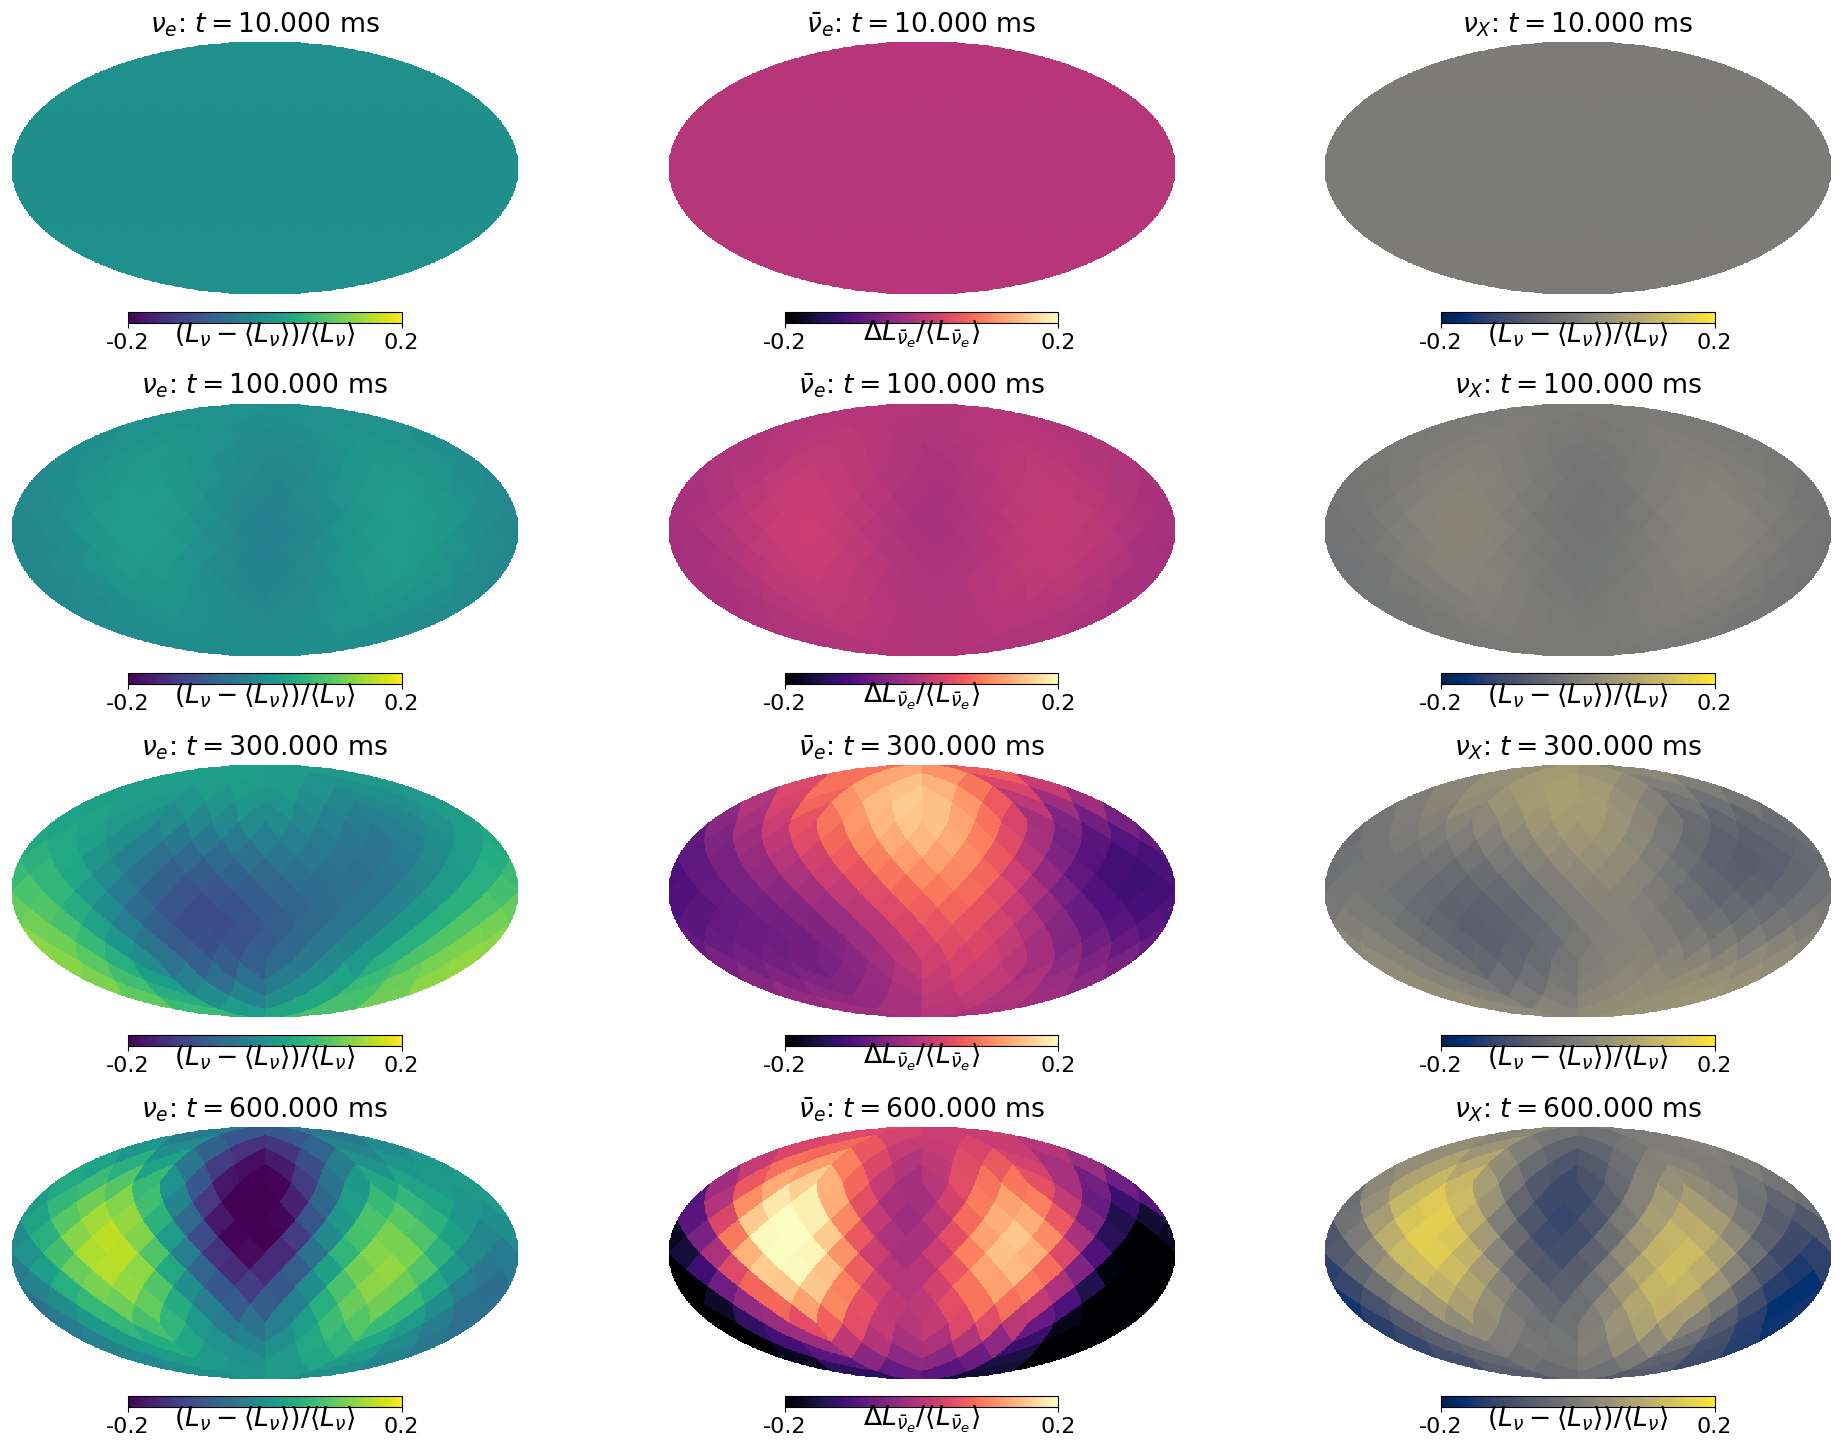

In [7]:
if healpy_available:
    times = np.asarray([10., 100., 300., 600.]) * u.ms
    nt = len(times)

    fig, axes = plt.subplots(nt,3, figsize=(8*3, nt*4.5))

    #- Get luminosity for a fixed list of times
    idx = [np.abs(t - model.time).argmin() for t in times]
    L_nue = model.luminosity[ThreeFlavor.NU_E].to('1e52*erg/s')[idx]
    L_nue_bar = model.luminosity[ThreeFlavor.NU_E_BAR].to('1e52*erg/s')[idx]
    L_numu = model.luminosity[ThreeFlavor.NU_MU].to('1e52*erg/s')[idx]

    vmin, vmax = -0.2, 0.2

    for i, t in enumerate(times):        
        ax = axes[i,0]
        plt.axes(ax)
        Lavg = np.average(L_nue[i])
        dL_on_L = (L_nue[i] - Lavg) / Lavg
        hp.mollview(dL_on_L, title=rf'$\nu_e$: $t=${t:.3f}',
                    unit=r'$(L_\nu - \langle L_\nu\rangle) / \langle L_\nu\rangle$', cmap='viridis',
                    min=vmin, max=vmax,
                    hold=True)
        
        ax = axes[i,1]
        plt.axes(ax)
        Lavg = np.average(L_nue_bar[i])
        dL_on_L = (L_nue_bar[i] - Lavg) / Lavg
        hp.mollview(dL_on_L, title=rf'$\bar{{\nu}}_e$: $t=${t:.3f}',
                    unit=r'$\Delta L_{\bar{\nu}_e}/\langle L_{\bar{\nu}_e}\rangle$', cmap='magma',
                    min=vmin, max=vmax,
                    hold=True)
        
        ax = axes[i,2]
        plt.axes(ax)
        Lavg = np.average(L_numu[i])
        dL_on_L = (L_numu[i] - Lavg) / Lavg
        hp.mollview(dL_on_L, title=rf'$\nu_X$: $t=${t:.3f}',
                    unit=r'$(L_\nu - \langle L_\nu\rangle) / \langle L_\nu\rangle$', cmap='cividis',
                    min=vmin, max=vmax,
                    hold=True)

### Superimpose $L_\nu(t,\theta,\varphi)$ at All Locations on the Sphere

Plot $L(t)$ at all locations as well as the average, and then the deviation from the average.

#### Electron Neutrinos

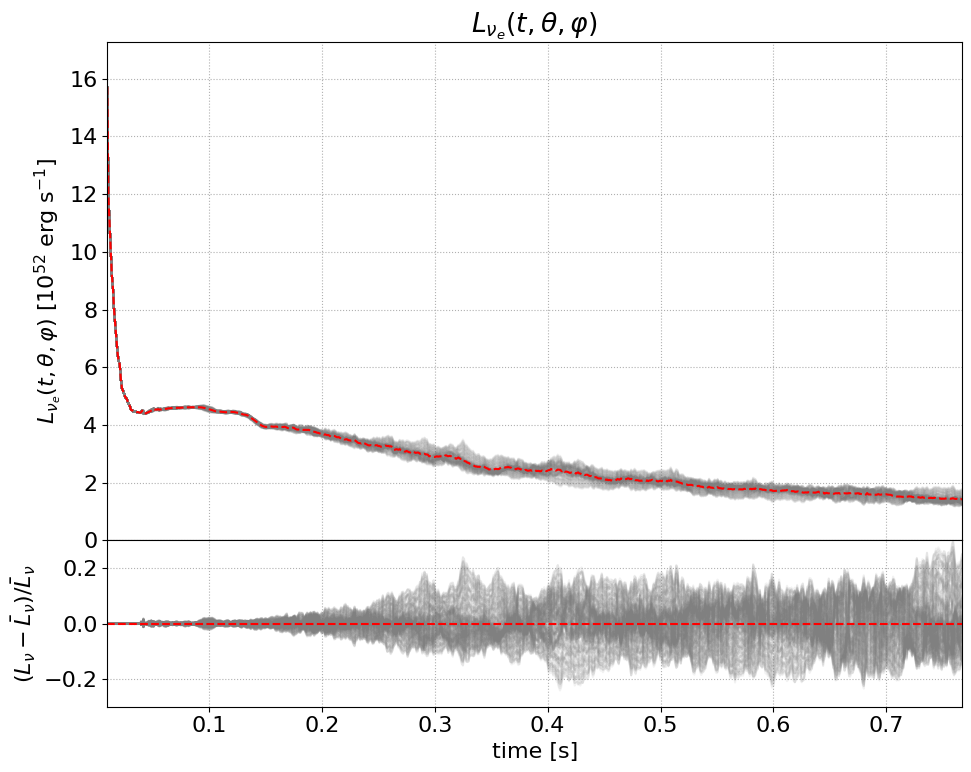

In [8]:
if healpy_available:
    #- get luminosity for all model times
    L_nue = model.luminosity[ThreeFlavor.NU_E].to('1e52*erg/s')
    L_nue_bar = model.luminosity[ThreeFlavor.NU_E_BAR].to('1e52*erg/s')
    L_numu = model.luminosity[ThreeFlavor.NU_MU].to('1e52*erg/s')
    
    Lavg = np.average(L_nue, axis=1)
    dL_over_L = (L_nue - Lavg[:, np.newaxis]) / Lavg[:, np.newaxis]

    fig, axes = plt.subplots(2, 1, figsize=(10, 8),
                             gridspec_kw={'height_ratios': [3, 1], 'hspace': 0},
                             sharex=True, tight_layout=True)

    ax = axes[0]
    ax.plot(model.time, L_nue, color='gray', alpha=0.05)
    ax.plot(model.time, Lavg, color='r', ls='--')
    ax.set(xlim=model.time[0::len(model.time)-1].value,
           ylabel=r'$L_{\nu_e}(t,\theta,\varphi)$ [$10^{52}$ erg s$^{-1}$]',
           ylim=(0, 1.1*np.max(L_nue).value),
           title=r'$L_{\nu_e}(t,\theta,\varphi)$')
    ax.grid(ls=':')

    ax = axes[1]
    ax.plot(model.time, dL_over_L, color='gray', alpha=0.1)
    ax.plot(model.time, np.zeros(model.time.shape), ls='--', color='r')
    ax.set(xlabel='time [s]',
           ylabel=r'$(L_\nu - \bar{L}_\nu)/\bar{L}_\nu$',
           ylim=(-0.3, 0.3))
    ax.grid(ls=':')

#### Electron Antineutrinos

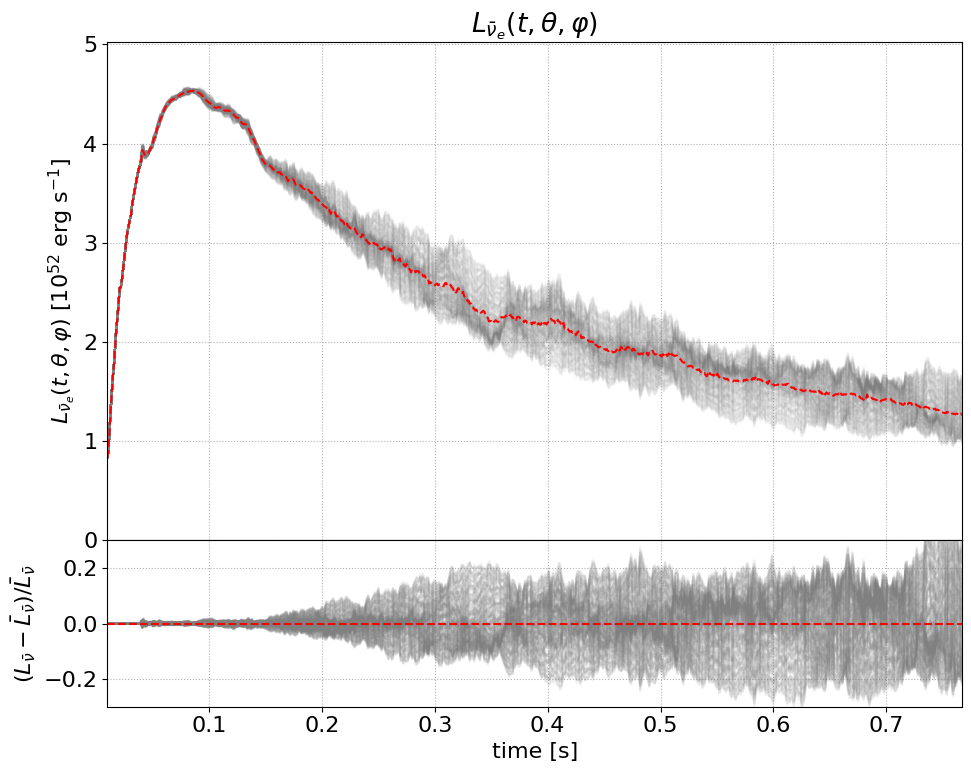

In [9]:
if healpy_available:
    Lavg = np.average(L_nue_bar, axis=1)
    dL_over_L = (L_nue_bar - Lavg[:, np.newaxis]) / Lavg[:, np.newaxis]

    fig, axes = plt.subplots(2, 1, figsize=(10, 8),
                             gridspec_kw={'height_ratios': [3, 1], 'hspace': 0},
                             sharex=True, tight_layout=True)

    ax = axes[0]
    ax.plot(model.time, L_nue_bar, color='gray', alpha=0.05)
    ax.plot(model.time, Lavg, color='r', ls='--')
    ax.set(xlim=model.time[0::len(model.time)-1].value,
           ylabel=r'$L_{\bar{\nu}_e}(t,\theta,\varphi)$ [$10^{52}$ erg s$^{-1}$]',
           ylim=(0, 1.1*np.max(L_nue_bar).value),
           title=r'$L_{\bar{\nu}_e}(t,\theta,\varphi)$')
    ax.grid(ls=':')

    ax = axes[1]
    ax.plot(model.time, dL_over_L, color='gray', alpha=0.1)
    ax.plot(model.time, np.zeros(model.time.shape), ls='--', color='r')
    ax.set(xlabel='time [s]',
           ylabel=r'$(L_\bar{\nu} - \bar{L}_\bar{\nu})/\bar{L}_\bar{\nu}$',
           ylim=(-0.3, 0.3))
    ax.grid(ls=':')

#### Flavor X (Stand-in for Mu and Tau Neutrinos)

Note that in this model, the mu and tau antineutrino flux is identical to the neutrino flux so we won't bother plotting it here.

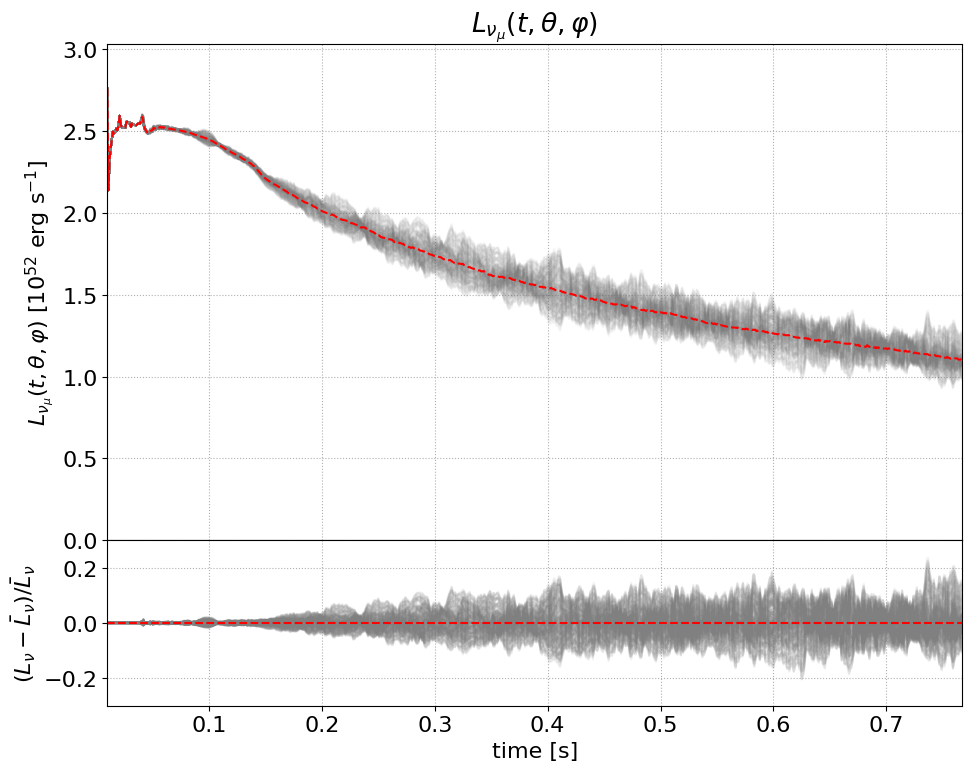

In [10]:
if healpy_available:
    Lavg = np.average(L_numu, axis=1)
    dL_over_L = (L_numu - Lavg[:,np.newaxis]) / Lavg[:,np.newaxis]

    fig, axes = plt.subplots(2,1, figsize=(10,8),
                        gridspec_kw = {'height_ratios':[3,1], 'hspace':0},
                        sharex=True, tight_layout=True)

    ax = axes[0]
    ax.plot(model.time, L_numu, color='gray', alpha=0.05)
    ax.plot(model.time, Lavg, color='r', ls='--')
    ax.set(xlim=model.time[0::len(model.time)-1].value,
            ylabel=r'$L_{\nu_\mu}(t,\theta,\varphi)$ [$10^{52}$ erg s$^{-1}$]',
            ylim=(0, 1.1*np.max(L_numu).value),
            title=r'$L_{\nu_\mu}(t,\theta,\varphi)$')
    ax.grid(ls=':')

    ax = axes[1]
    ax.plot(model.time, dL_over_L, color='gray', alpha=0.1)
    ax.plot(model.time, np.zeros(model.time.shape), ls='--', color='r')
    ax.set(xlabel='time [s]',
            ylabel=r'$(L_\nu - \bar{L}_\nu)/\bar{L}_\nu$',
            ylim=(-0.3, 0.3))
    ax.grid(ls=':');